# Grad-CAM Visualization — YOLOv8s vs YOLOv8m
**Dataset:** FracAtlas Hand Bone Fracture Detection  
**Keperluan:** Jurnal Sinta 3  
**Library:** `pytorch-grad-cam` (HiResCAM)

> **HiResCAM** dipilih karena menghasilkan heatmap resolusi tinggi yang lebih akurat secara spasial dibandingkan GradCAM standar — ideal untuk domain medis.

## 1. Install Dependencies

In [58]:
!pip install grad-cam ultralytics opencv-python matplotlib -q

## 2. Imports

In [59]:
import cv2
import numpy as np
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO

from pytorch_grad_cam import HiResCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

print('pytorch_grad_cam OK')
print('torch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

pytorch_grad_cam OK
torch version: 2.7.1+cu118
CUDA available: True


## 3. Konfigurasi Path

In [60]:
BASE_DIR = Path("D:/Project Medical Object Detection/FracAtlas")

MODEL_CONFIGS = {
    "YOLOv8s": {
        "weight" : BASE_DIR / "runs/detect/fracatlas_yolov8s/weights/best.pt",
        "color"  : "#4FC3F7",
    },
    "YOLOv8m": {
        "weight" : BASE_DIR / "runs/detect/fracatlas_yolov8m/fracatlas_yolov8m/weights/best.pt",
        "color"  : "#EF9A9A",
    },
}

TEST_IMAGE_DIR = BASE_DIR / "yolo_dataset_hand_oversampled/test/images"
OUTPUT_DIR     = BASE_DIR / "gradcam_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Pilih berapa gambar yang diproses ----
N_IMAGES       = 6
CONF_THRESHOLD = 0.25
IMG_SIZE       = 640

# Layer target — C2f terakhir backbone YOLOv8 (index 8)
# Layer target per model — disesuaikan dengan arsitektur
TARGET_LAYER_MAP = {
    "YOLOv8s": 8,   # last C2f layer (detail spasial tinggi)
    "YOLOv8m": 9,   # SPPF layer (lebih global, kurang noise)
}
HEATMAP_THRESHOLD = 0.15  # noise floor: nilai < threshold di-nol-kan

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Validasi weight tersedia
for name, cfg in MODEL_CONFIGS.items():
    status = "✓" if cfg["weight"].exists() else "✗ TIDAK DITEMUKAN"
    print(f"  {status}  {name}: {cfg['weight']}")

Device: cuda
  ✓  YOLOv8s: D:\Project Medical Object Detection\FracAtlas\runs\detect\fracatlas_yolov8s\weights\best.pt
  ✓  YOLOv8m: D:\Project Medical Object Detection\FracAtlas\runs\detect\fracatlas_yolov8m\fracatlas_yolov8m\weights\best.pt


## 4. Wrapper Model untuk pytorch-grad-cam

`pytorch_grad_cam` butuh model yang menerima tensor `[B, C, H, W]` dan mengembalikan satu tensor.  
YOLOv8 mengembalikan tuple — wrapper ini memilih output yang relevan.

In [61]:
import torch.nn as nn

class YOLOv8Wrapper(nn.Module):
    """
    Wrapper agar backbone YOLOv8 kompatibel dengan pytorch-grad-cam.
    Output: tensor skor confidence [B, num_anchors] — digunakan sebagai
    target oleh HiResCAM.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model  # ultralytics DetectionModel

    def forward(self, x):
        preds = self.model(x)
        # preds bisa berupa tuple; ambil elemen pertama
        if isinstance(preds, (tuple, list)):
            preds = preds[0]
        # Shape biasanya [B, 5, num_anchors] → ambil baris ke-4 (objectness)
        if preds.ndim == 3:
            return preds[:, 4, :]   # [B, num_anchors]
        return preds


def build_cam(weight_path: str, model_name: str):
    """Load model, buat wrapper, buat HiResCAM engine."""
    yolo    = YOLO(weight_path)
    det_model = yolo.model          # ultralytics DetectionModel
    det_model.to(DEVICE).eval()
    det_model.requires_grad_(True)

    wrapped = YOLOv8Wrapper(det_model)
    wrapped.to(DEVICE).eval()

    target_layer_idx = TARGET_LAYER_MAP.get(model_name, 8)
    target_layer = det_model.model[target_layer_idx]

    cam = HiResCAM(
        model        = wrapped,
        target_layers= [target_layer],
    )
    # Simpan yolo instance untuk inferensi deteksi
    cam._yolo_instance = yolo
    return cam


print("Memuat model...")
cams   = {}   # HiResCAM engine
models = {}   # YOLO instance untuk bounding-box inference

for name, cfg in MODEL_CONFIGS.items():
    if not cfg["weight"].exists():
        print(f"  [SKIP] {name}")
        continue
    cams[name]   = build_cam(str(cfg["weight"]), name)
    models[name] = cams[name]._yolo_instance
    print(f"  ✓ {name} siap")

print("Semua model loaded.")

Memuat model...
  ✓ YOLOv8s siap
  ✓ YOLOv8m siap
Semua model loaded.


## 5. Fungsi Helper

In [62]:
def preprocess_image(img_path: Path, img_size: int = 640,
                     crop_artifacts: bool = True):
    """Baca & resize gambar → (img_rgb float [0,1], tensor [1,3,H,W])."""
    bgr = cv2.imread(str(img_path))
    if bgr is None:
        raise FileNotFoundError(img_path)
    bgr = cv2.resize(bgr, (img_size, img_size))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_f = rgb.astype(np.float32) / 255.0          # [H, W, 3] float
    if crop_artifacts:
        # Crop 10% margin untuk menghilangkan marker R/L, logo, border
        bgr_cropped = remove_artifacts(bgr)
        rgb_cropped = cv2.cvtColor(bgr_cropped, cv2.COLOR_BGR2RGB)
        rgb_f = rgb_cropped.astype(np.float32) / 255.0
        tensor = torch.from_numpy(rgb_f).permute(2,0,1).unsqueeze(0)
    else:
        tensor = torch.from_numpy(rgb_f).permute(2,0,1).unsqueeze(0)
    return rgb_f, tensor


def get_detections(yolo_model: YOLO, img_path: Path,
                   conf: float = 0.25, img_size: int = 640):
    """Jalankan YOLO predict dan kembalikan list (x1,y1,x2,y2,conf)."""
    orig = cv2.imread(str(img_path))
    oh, ow = orig.shape[:2]
    results = yolo_model.predict(str(img_path), conf=conf,
                                 imgsz=img_size, verbose=False)
    boxes = []
    if results and results[0].boxes is not None:
        for box in results[0].boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            # scale ke display size
            x1 = x1 * img_size / ow;  x2 = x2 * img_size / ow
            y1 = y1 * img_size / oh;  y2 = y2 * img_size / oh
            boxes.append((x1, y1, x2, y2, float(box.conf[0])))
    return boxes

def remove_artifacts(img_bgr):
    """Hilangkan marker R/L, logo, dan border putih pada X-ray.
    Strategi: crop 10% dari tiap tepi, lalu mask area pinggir.
    """
    h, w = img_bgr.shape[:2]
    crop_margin = int(min(h, w) * 0.10)
    return img_bgr[crop_margin:h-crop_margin, crop_margin:w-crop_margin]

def apply_heatmap_threshold(heatmap, threshold=HEATMAP_THRESHOLD):
    """Terapkan threshold untuk menekan noise pada heatmap."""
    heatmap[heatmap < threshold] = 0.0
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    return heatmap


print("Helper functions defined.")

Helper functions defined.


## 6. Hasilkan Grad-CAM (HiResCAM) untuk Semua Gambar

In [63]:
# Kumpulkan gambar test
img_paths = sorted([
    p for p in TEST_IMAGE_DIR.iterdir()
    if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}
])[:N_IMAGES]

print(f"Memproses {len(img_paths)} gambar...\n")

all_results = []  # list of (img_name, rgb_f, {model_name: (heatmap, overlay, boxes)})

for img_path in img_paths:
    print(f"[{img_path.name}]")

    # Crop artifacts (R/L markers, logos, borders)
    rgb_f, tensor = preprocess_image(img_path, IMG_SIZE)
    results_per_model = {}

    for model_name, cam_engine in cams.items():
        # --- HiResCAM ---
        # targets=None -> otomatis maskimalkan output tertinggi
        tensor_device = tensor.to(DEVICE)
        tensor_device.requires_grad_(True)

        grayscale_cam = cam_engine(
            input_tensor=tensor_device,
            targets=None,
            aug_smooth=False,
            eigen_smooth=False
        )  # [1, H, W]

        # Terapkan threshold noise
        heatmap = apply_heatmap_threshold(grayscale_cam[0])

        # Overlay dari pytorch_grad_cam (hasilkan RGB uint8)
        overlay = show_cam_on_image(rgb_f, heatmap, use_rgb=True, colormap=cv2.COLORMAP_JET)

        # Bounding box dari YOLO predict
        boxes = get_detections(models[model_name], img_path, CONF_THRESHOLD, IMG_SIZE)

        results_per_model[model_name] = (heatmap, overlay, boxes)
        n_det = len(boxes)
        print(f"  {model_name}: {n_det} deteksi, heatmap max={heatmap.max():.3f}")

    all_results.append((img_path.name, rgb_f, results_per_model))

print("\nSelesai!")


Memproses 6 gambar...

[IMG0000035_orig.jpg]
  YOLOv8s: 0 deteksi, heatmap max=1.000
  YOLOv8m: 0 deteksi, heatmap max=1.000
[IMG0000045_orig.jpg]
  YOLOv8s: 0 deteksi, heatmap max=1.000
  YOLOv8m: 0 deteksi, heatmap max=1.000
[IMG0000057_orig.jpg]
  YOLOv8s: 1 deteksi, heatmap max=1.000
  YOLOv8m: 1 deteksi, heatmap max=1.000
[IMG0000059_aug1.jpg]
  YOLOv8s: 1 deteksi, heatmap max=1.000
  YOLOv8m: 1 deteksi, heatmap max=1.000
[IMG0000087_orig.jpg]
  YOLOv8s: 0 deteksi, heatmap max=1.000
  YOLOv8m: 1 deteksi, heatmap max=1.000
[IMG0000100_aug0.jpg]
  YOLOv8s: 1 deteksi, heatmap max=1.000
  YOLOv8m: 0 deteksi, heatmap max=1.000

Selesai!


## 7. Visualisasi Per-Gambar (Original | Heatmap | Overlay+BBox)

  Saved: hirescam_IMG0000035_orig.png


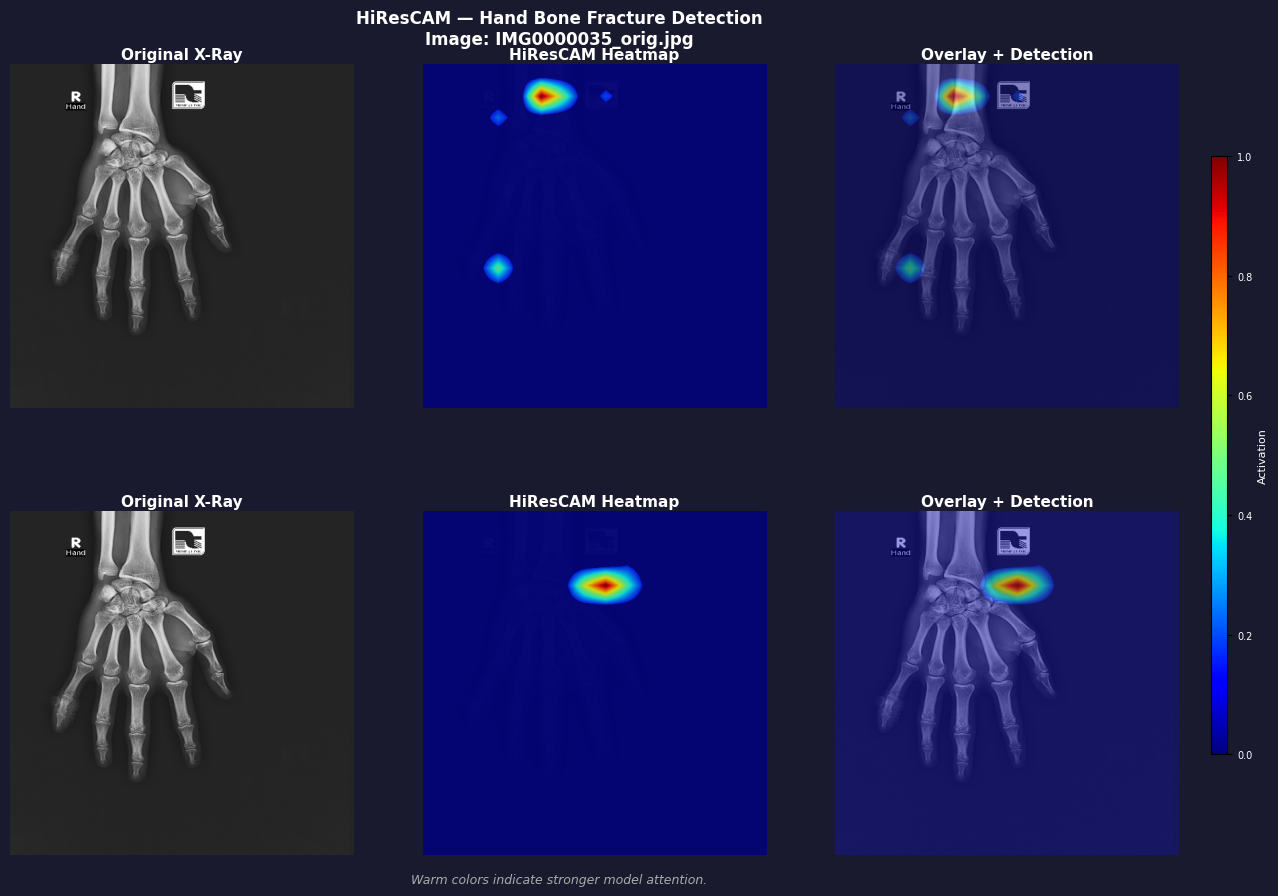

  Saved: hirescam_IMG0000045_orig.png


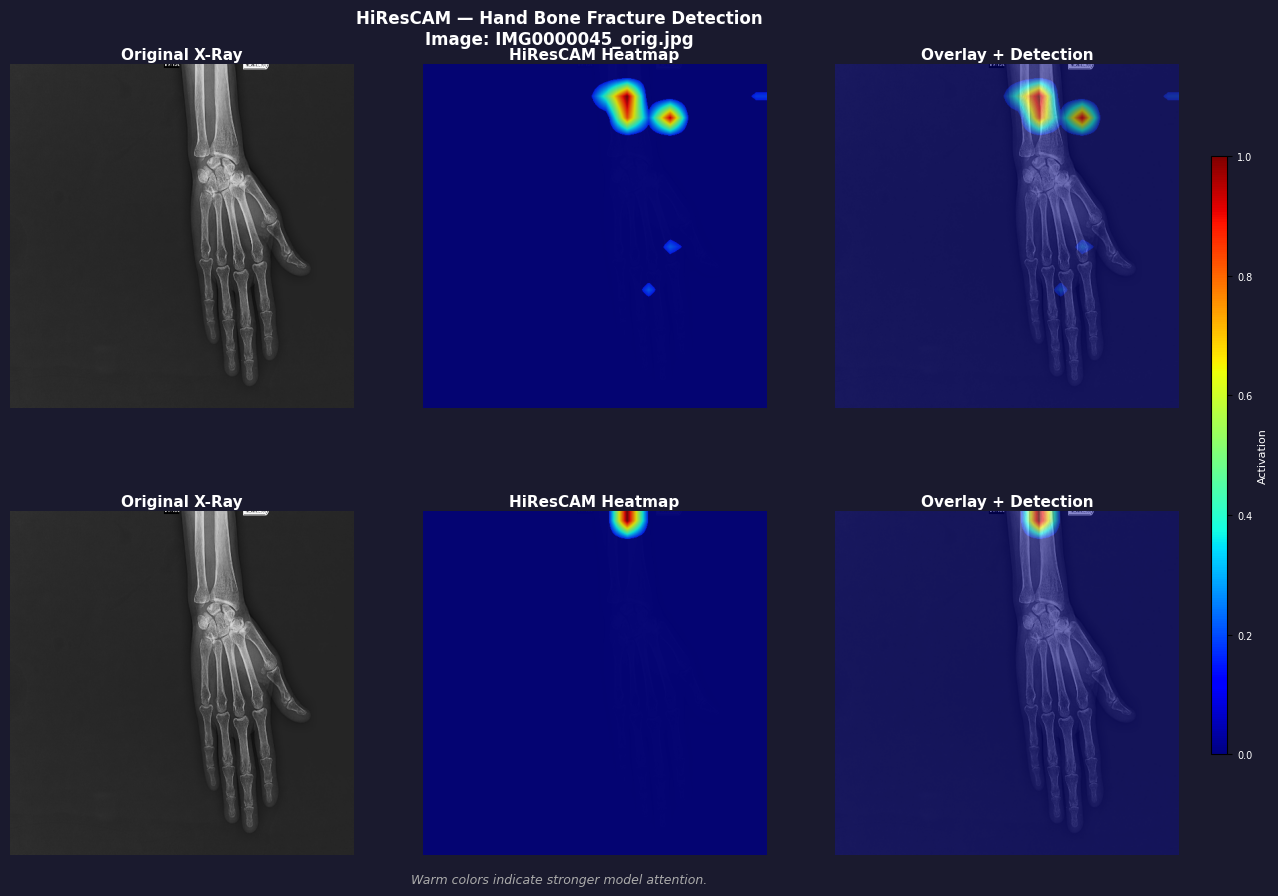

  Saved: hirescam_IMG0000057_orig.png


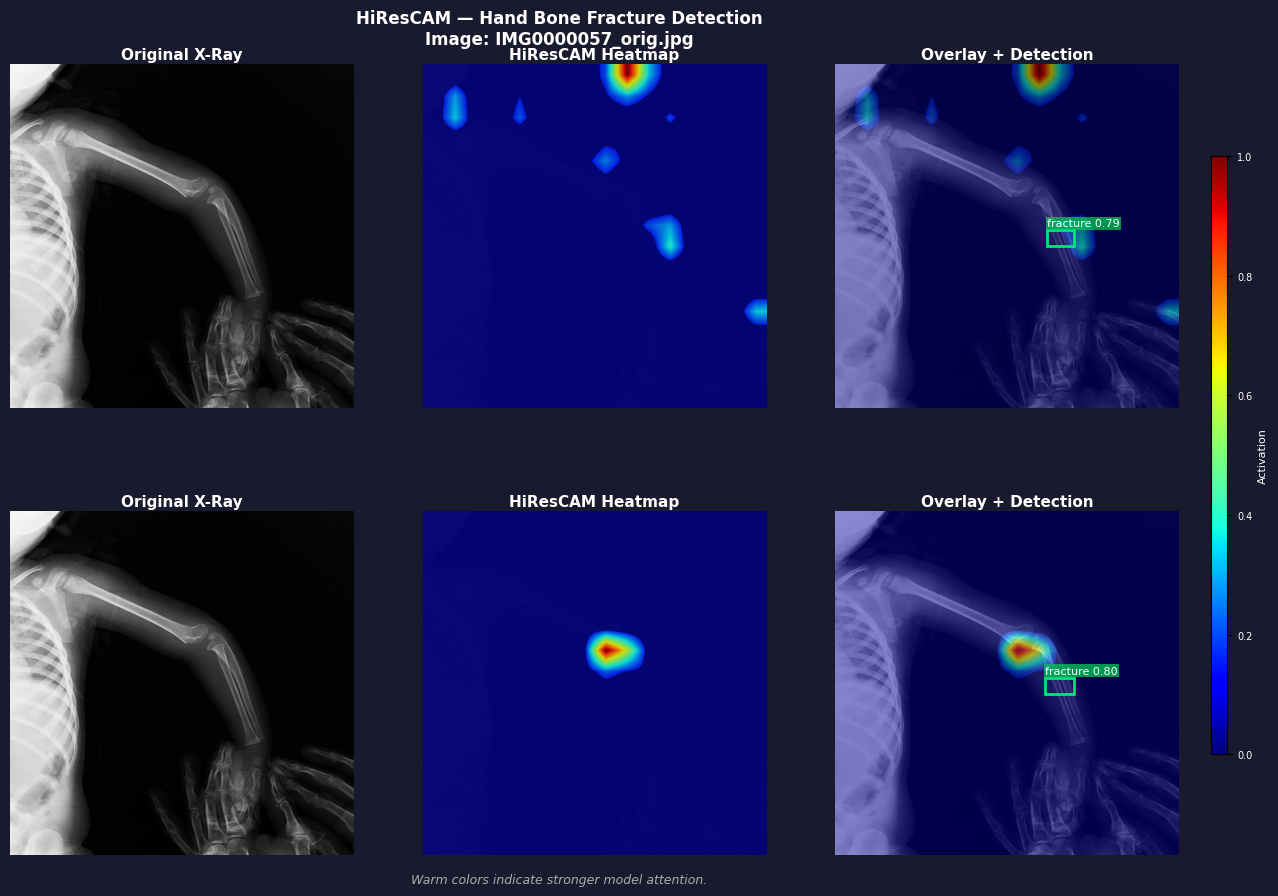

  Saved: hirescam_IMG0000059_aug1.png


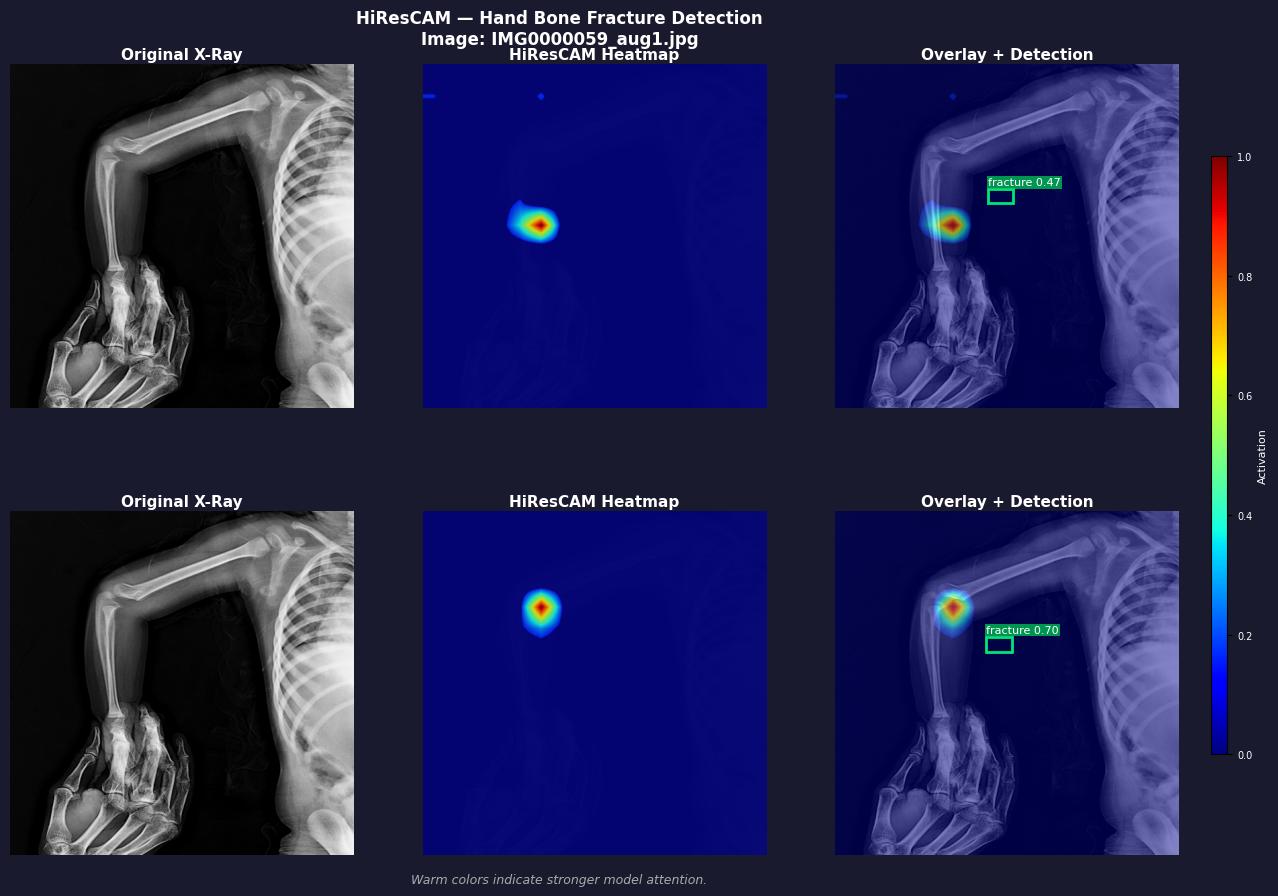

  Saved: hirescam_IMG0000087_orig.png


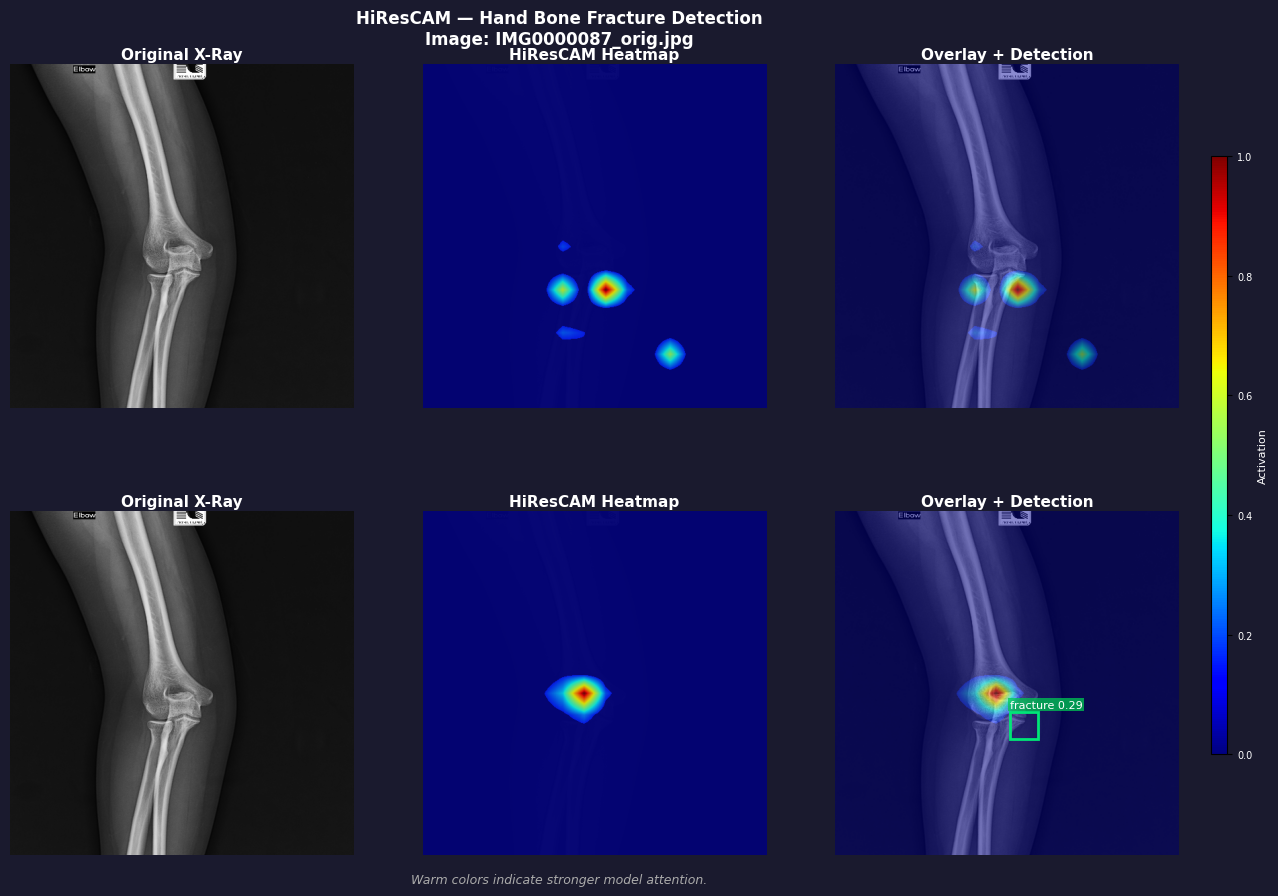

  Saved: hirescam_IMG0000100_aug0.png


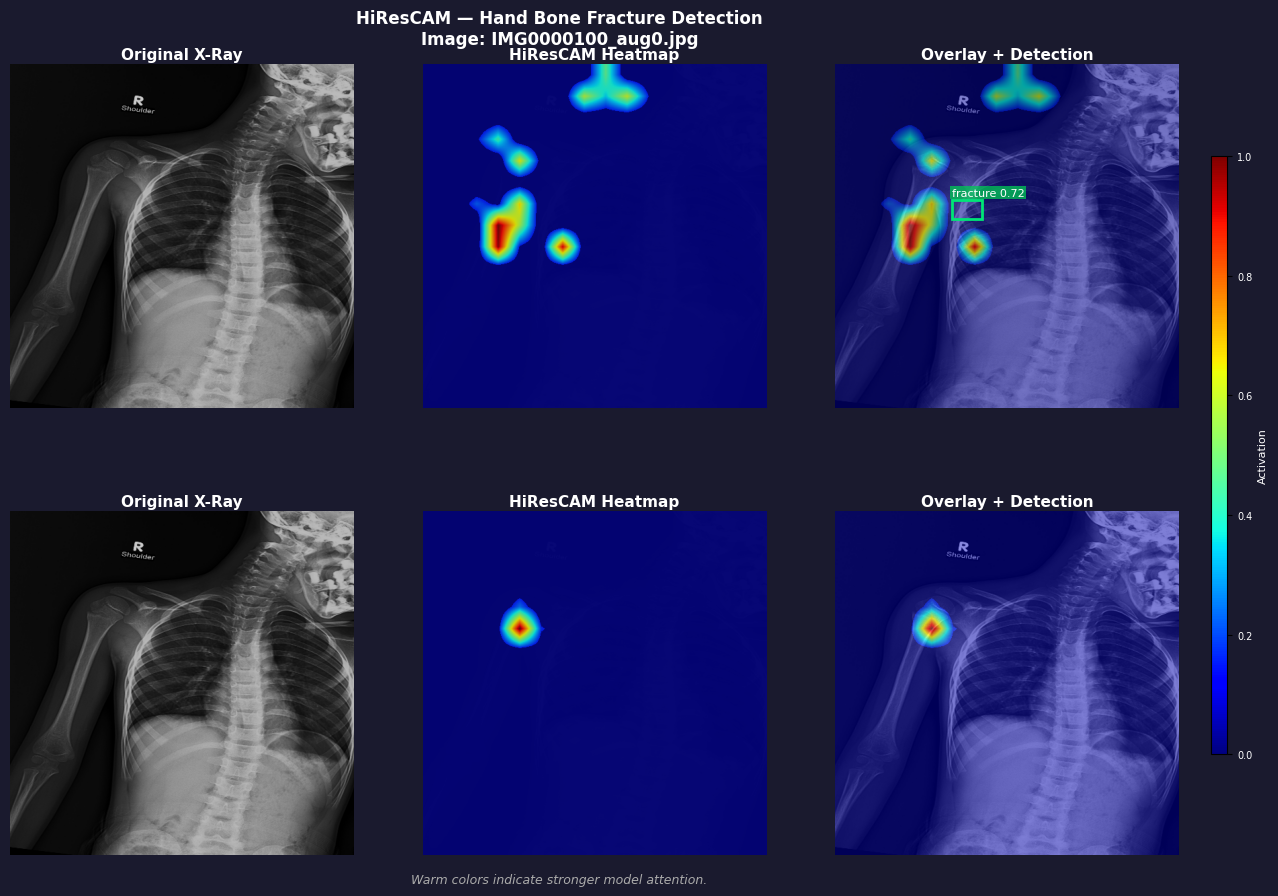

In [64]:
def plot_comparison(img_name, rgb_f, results_per_model, save_path=None):
    n = len(results_per_model)
    fig = plt.figure(figsize=(14, 4.6 * n), facecolor='#1a1a2e')
    gs  = GridSpec(n, 3, figure=fig,
                   hspace=0.30, wspace=0.05,
                   left=0.09, right=0.96, top=0.90, bottom=0.04)

    for row, (model_name, (heatmap, overlay, boxes)) in enumerate(results_per_model.items()):
        color = MODEL_CONFIGS[model_name]["color"]

        # Col 0: Original
        ax0 = fig.add_subplot(gs[row, 0])
        ax0.imshow(rgb_f)
        ax0.set_title("Original X-Ray", color='white', fontsize=11, fontweight='bold', pad=4)
        ax0.set_ylabel(model_name, color=color, fontsize=12,
                       fontweight='bold', rotation=90, labelpad=6)
        ax0.axis('off')

        # Col 1: HiResCAM heatmap
        ax1 = fig.add_subplot(gs[row, 1])
        ax1.imshow(rgb_f, alpha=0.15)
        ax1.imshow(heatmap, cmap='jet', alpha=0.85, vmin=0, vmax=1)
        ax1.set_title("HiResCAM Heatmap", color='white', fontsize=11, fontweight='bold', pad=4)
        ax1.axis('off')

        # Col 2: Overlay + BBox
        ax2 = fig.add_subplot(gs[row, 2])
        ax2.imshow(overlay)
        for (x1, y1, x2, y2, conf) in boxes:
            ax2.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                lw=2, edgecolor='#00E676', facecolor='none'))
            ax2.text(x1, y1-6, f"fracture {conf:.2f}",
                     fontsize=8, color='white',
                     bbox=dict(fc='#00C853', alpha=0.75, pad=1, ec='none'))
        ax2.set_title("Overlay + Detection", color='white', fontsize=11, fontweight='bold', pad=4)
        ax2.axis('off')

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(0, 1))
    sm.set_array([])
    cax = fig.add_axes([0.965, 0.15, 0.012, 0.65])
    cb  = fig.colorbar(sm, cax=cax)
    cb.set_label('Activation', color='white', fontsize=8)
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white', fontsize=7)

    fig.suptitle(f"HiResCAM — Hand Bone Fracture Detection\nImage: {img_name}",
                 fontsize=12, fontweight='bold', color='white', y=0.96)

    # Caption legenda
    fig.text(0.5, 0.01, "Warm colors indicate stronger model attention.",
             ha='center', fontsize=9, color='#aaaaaa', fontstyle='italic')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
        print(f"  Saved: {Path(save_path).name}")
    plt.show()
    plt.close()


for img_name, rgb_f, res in all_results:
    out = OUTPUT_DIR / f"hirescam_{Path(img_name).stem}.png"
    plot_comparison(img_name, rgb_f, res, save_path=out)


## 8. Journal-Ready Grid Figure

Grid layout: **baris = model**, **kolom = gambar** — siap insert ke paper.

Journal grid saved: journal_hirescam_grid_p1.png


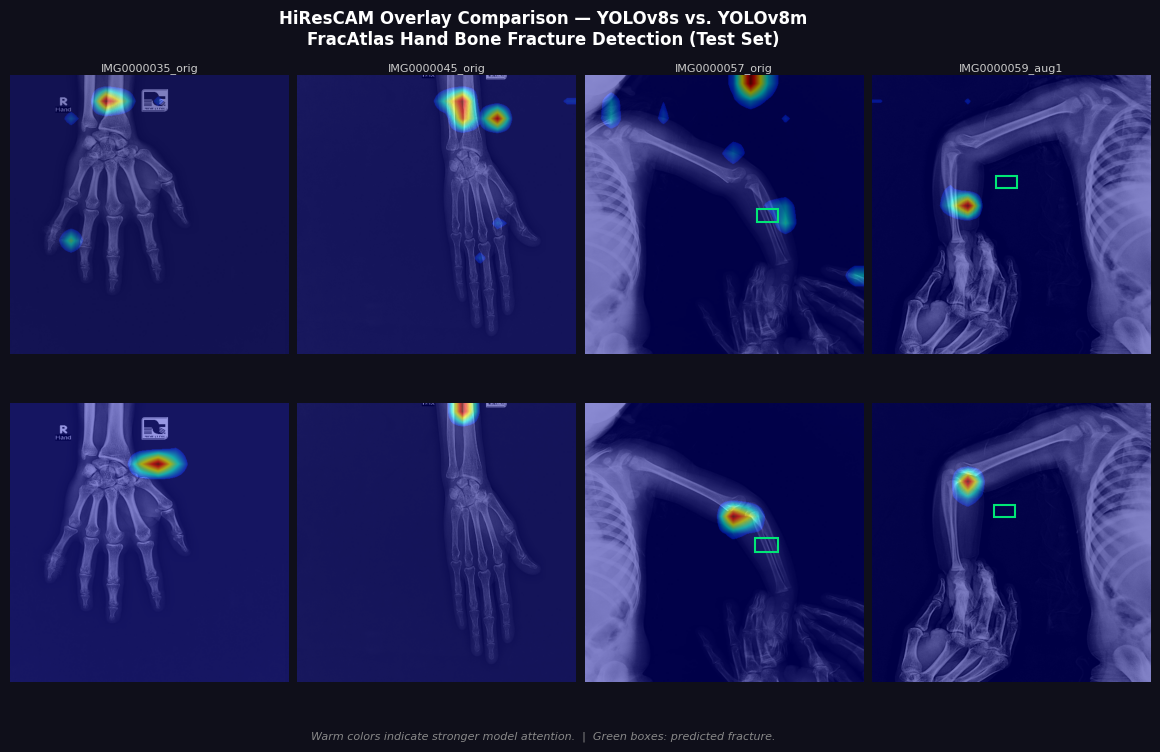

Journal grid saved: journal_hirescam_grid_p2.png


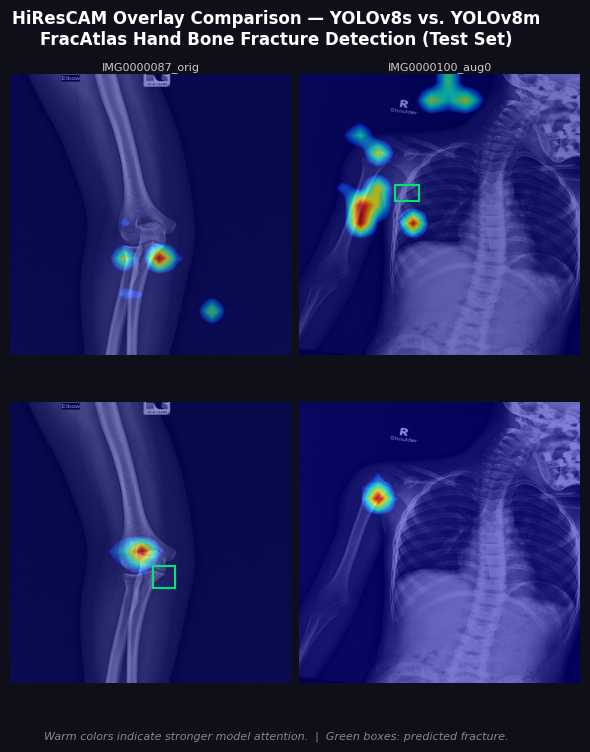

In [65]:
def make_journal_grid(results_list, output_path, cols=4):
    """
    results_list : list of (img_name, rgb_f, {model: (heatmap, overlay, boxes)})
    Layout: rows=n_models, cols=n_images
    """
    n     = len(results_list)
    names = list(MODEL_CONFIGS.keys())
    rows  = len(names)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 3.1, rows * 3.3 + 1.0),
                             facecolor='#0f0f1a')
    fig.subplots_adjust(hspace=0.06, wspace=0.03,
                        top=0.90, bottom=0.06, left=0.07, right=0.99)

    # Pastikan axes selalu 2-D
    if rows == 1:
        axes = axes[np.newaxis, :]
    if cols == 1:
        axes = axes[:, np.newaxis]

    for c in range(cols):
        if c >= n:
            for r in range(rows):
                axes[r, c].axis('off')
            continue

        img_name, rgb_f, res = results_list[c]

        for r, mname in enumerate(names):
            ax = axes[r, c]
            if mname not in res:
                ax.axis('off')
                continue

            _, overlay, boxes = res[mname]
            ax.imshow(overlay)

            for (x1, y1, x2, y2, conf) in boxes:
                ax.add_patch(patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    lw=1.5, edgecolor='#00E676', facecolor='none'))

            ax.axis('off')

            # Label model (kolom pertama)
            if c == 0:
                ax.set_ylabel(mname, fontsize=12, fontweight='bold',
                              color=MODEL_CONFIGS[mname]["color"],
                              rotation=90, labelpad=4)

            # Judul gambar (baris pertama)
            if r == 0:
                stem = Path(img_name).stem
                label = stem[:16] + "…" if len(stem) > 16 else stem
                ax.set_title(label, fontsize=8, color='#cccccc', pad=3)

    fig.suptitle(
        "HiResCAM Overlay Comparison \u2014 YOLOv8s vs. YOLOv8m\n"
        "FracAtlas Hand Bone Fracture Detection (Test Set)",
        fontsize=12, fontweight='bold', color='white', y=0.965)

    # Caption legenda
    fig.text(0.5, 0.005, "Warm colors indicate stronger model attention.  |  Green boxes: predicted fracture.",
             ha='center', fontsize=8, color='#888888', fontstyle='italic')

    plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='#0f0f1a')
    print(f"Journal grid saved: {Path(output_path).name}")
    plt.show()
    plt.close()


# Bagi jadi halaman 4-kolom
pages = [all_results[i:i+4] for i in range(0, len(all_results), 4)]
for i, page in enumerate(pages, 1):
    make_journal_grid(
        page,
        output_path=str(OUTPUT_DIR / f"journal_hirescam_grid_p{i}.png"),
        cols=len(page)
    )


## 9. Summary Output

In [66]:
print(f"\n✅ Semua output tersimpan di: {OUTPUT_DIR}\n")
for f in sorted(OUTPUT_DIR.glob("hirescam*")) + sorted(OUTPUT_DIR.glob("journal_hirescam*")):
    print(f"  • {f.name}  ({f.stat().st_size // 1024} KB)")


✅ Semua output tersimpan di: D:\Project Medical Object Detection\FracAtlas\gradcam_output

  • hirescam_IMG0000035_orig.png  (522 KB)
  • hirescam_IMG0000045_orig.png  (656 KB)
  • hirescam_IMG0000057_orig.png  (746 KB)
  • hirescam_IMG0000059_aug1.png  (1052 KB)
  • hirescam_IMG0000087_orig.png  (667 KB)
  • hirescam_IMG0000100_aug0.png  (998 KB)
  • journal_hirescam_grid_p1.png  (1448 KB)
  • journal_hirescam_grid_p2.png  (848 KB)
